In [ ]:
%matplotlib inline
# %matplotlib notebook
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
from scipy.stats import linregress
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779101039.984094   40274 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779101040.014525   40274 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779101041.154509   40274 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [3]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

# Noiseless Dataset

Load Dataset

In [4]:
rho_arr_noiseless = np.load('../data/unitary_4x4_101_1000_noiseless.npy', mmap_mode="r")
X_train_noiseless, X_test_noiseless, y_train_noiseless, y_test_noiseless = train_test_split(rho_arr_noiseless, alpha_arr, random_state=42)
concurrence_noiseless_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noiseless])

Define Hyperparameters and load trained VAE:

In [5]:
batch_size = 64
beta = 0.0
learning_rate = 0.0001
lat_dim = 1

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, "relu", "tanh")
encoder.load_weights("../data/encoder_noiseless.h5")
decoder.load_weights("../data/decoder_noiseless.h5")

vae_noiseless = vae_utils.VAE(encoder, decoder, beta)
vae_noiseless.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
# vae_noiseless.fit(X_test_noiseless, epochs=1, batch_size=64, verbose=1) 

z_mean_noiseless, z_log_var_noiseless, z_noiseless = vae_noiseless.encoder.predict(X_test_noiseless)

790/790 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step


Investigate Latent Space

In [6]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

# Noisy Dataset  $0.75\beta$

Load Dataset

In [7]:
rho_arr_noisy = np.load('../data/unitary_4x4_101_1000.npy', mmap_mode="r")
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(rho_arr_noisy, alpha_arr, random_state=42)
concurrence_noisy_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noisy])

Load trained VAE and define Hyperparameters:

In [8]:
batch_size = 64
beta = 0.75
learning_rate = 0.0001
lat_dim = 1
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)
encoder.load_weights("../data/encoder_noise_075beta.h5")
decoder.load_weights("../data/decoder_noise_075beta.h5")

vae_noisy = vae_utils.VAE(encoder, decoder, beta)
vae_noisy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

z_mean_noisy, z_log_var_noisy, z_noisy = vae_noisy.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step


# 3D Latent Space

In [9]:
batch_size = 64
beta = 0.0
learning_rate = 0.0001
lat_dim = 3
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)

encoder.load_weights("../data/encoder_3lv_00beta_ramp.h5")
decoder.load_weights("../data/decoder_3lv_00beta_ramp.h5")

vae_3d = vae_utils.VAE(encoder, decoder, beta)
vae_3d.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
# vae_3d.fit(X_test_noisy, epochs=1, batch_size=64, verbose=1) 

z_mean_3d, _, _ = vae_3d.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step


# Figures 

In [11]:
lat_arr = np.arange(1,9)
n_exp = 9

recon_loss_noiseless = np.zeros((len(lat_arr),n_exp, 1))
recon_loss_noise = np.zeros((len(lat_arr),n_exp, 1))
recon_loss_noise_075 = np.zeros((len(lat_arr),n_exp, 1))


for cnt_1, inx in enumerate(lat_arr):
    for cnt_2 in range(n_exp):
        read_dictionary = np.load('../data/no_0beta_latent/history_{}_1_{}.npy'.format(inx,cnt_2),allow_pickle='TRUE').item()
        recon_loss_noiseless[cnt_1][cnt_2] = read_dictionary["reconstruction_loss"][-1]
        
        read_dictionary = np.load('../data/noise_0beta_latent/history_{}_1_{}.npy'.format(inx,cnt_2),allow_pickle='TRUE').item()
        recon_loss_noise[cnt_1][cnt_2] = read_dictionary["reconstruction_loss"][-1]
        
        read_dictionary = np.load('../data/noise_075beta_latent/history_{}_1_{}.npy'.format(inx,cnt_2),allow_pickle='TRUE').item()
        recon_loss_noise_075[cnt_1][cnt_2] = read_dictionary["reconstruction_loss"][-1]

av_recon_loss_arr_noiseless = np.average(recon_loss_noiseless,axis=1)
std_recon_loss_arr_noiseless = np.std(recon_loss_noiseless,axis=1)

av_recon_loss_arr_noise = np.average(recon_loss_noise,axis=1)
std_recon_loss_arr_noise = np.std(recon_loss_noise,axis=1)

av_recon_loss_arr_noise_075 = np.average(recon_loss_noise_075,axis=1)
std_recon_loss_arr_noise_075 = np.std(recon_loss_noise_075,axis=1)

In [12]:
selected_alpha_noiseless, selected_conc_noiseless, selected_z_noiseless, pred_conc_noiseless, pred_alpha_noiseless, fitobj_conc_noiseless, fitobj_alpha_noiseless = vae_utils.gen_plot_data(rho_arr_noiseless, vae_noiseless, scan_arr)  
selected_alpha_noisy, selected_conc_noisy, selected_z_noisy, pred_conc_noisy, pred_alpha_noisy, fitobj_conc_noisy, fitobj_alpha_noisy = vae_utils.gen_plot_data(rho_arr_noisy, vae_noisy, scan_arr)  
selected_alpha_generalized, selected_conc_generalized, selected_z_generalized, pred_conc_generalized, pred_alpha_generalized, fitobj_conc_generalized, fitobj_alpha_generalized = vae_utils.gen_plot_data(rho_arr_noiseless, vae_noisy, scan_arr)      

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [13]:
rho_qobjs = [qt.Qobj(dm.reshape(4, 4), dims=[[2, 2], [2, 2]]) for dm in X_test_noisy]
concurrence_arr = np.array([qt.concurrence(rho) for rho in rho_qobjs])
vn_entropy_arr = np.array([qt.entropy_vn(rho.ptrace(0), base=2) for rho in rho_qobjs])
log_negativity_arr = np.array([qt.negativity(rho, 1, logarithmic=True) for rho in rho_qobjs])

concurrence_arr, vn_entropy_arr, log_negativity_arr

/home/felix/vscode/Quantum-State-VAE/.venv/lib/python3.12/site-packages/qutip/core/data/expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


(array([0.99211469, 0.72896862, 0.64944804, ..., 0.01570731, 0.48175365,
        0.99002365], shape=(25250,)),
 array([9.88638917e-01, 6.28842644e-01, 5.28777116e-01, ...,
        9.51620047e-04, 3.34732266e-01, 9.85631208e-01], shape=(25250,)),
 array([0.99430072, 0.78991169, 0.72198334, ..., 0.02248474, 0.56730563,
        0.99278558], shape=(25250,)))

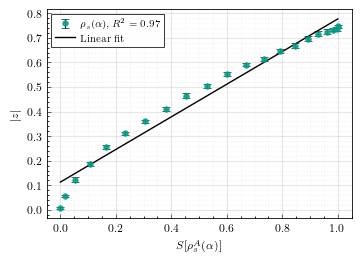

In [14]:
z_abs = np.abs(z_mean_noisy[:, 0]).flatten()
vn_x = vn_entropy_arr.flatten()
linent_x = np.array([qt.entropy_linear(rho.ptrace(0)) for rho in rho_qobjs]).flatten()
# linent_x = np.array([qt.entanglement_of_formation(rho) for rho in rho_qobjs]).flatten()

alpha_x = y_test_noisy.flatten()

# Select 21 alpha values and sample 10 states per alpha for aggregated points.
unique_alpha = np.unique(alpha_x)
alpha_idx = np.linspace(0, len(unique_alpha) - 1, 21, dtype=int)
alpha_sel = unique_alpha[alpha_idx]
rng = np.random.default_rng(42)

vn_mean, vn_std = [], []
linent_mean, linent_std = [], []
z_mean_sel, z_std_sel = [], []

for a in alpha_sel:
    inx = np.where(np.isclose(alpha_x, a))[0]
    pick = rng.choice(inx, size=10, replace=False)

    vn_s = vn_x[pick]
    linent_s = linent_x[pick]
    z_s = z_abs[pick]

    vn_mean.append(np.mean(vn_s))
    vn_std.append(np.std(vn_s))
    linent_mean.append(np.mean(linent_s))
    linent_std.append(np.std(linent_s))
    z_mean_sel.append(np.mean(z_s))
    z_std_sel.append(np.std(z_s))

vn_mean = np.array(vn_mean)
vn_std = np.array(vn_std)
linent_mean = np.array(linent_mean)
linent_std = np.array(linent_std)
z_mean_sel = np.array(z_mean_sel)
z_std_sel = np.array(z_std_sel)

fit_vn = np.poly1d(np.polyfit(vn_mean, z_mean_sel, 1))
fit_linent = np.poly1d(np.polyfit(linent_mean, z_mean_sel, 1))

_, _, r_vn, _, _ = linregress(vn_mean, z_mean_sel)
_, _, r_linent, _, _ = linregress(linent_mean, z_mean_sel)

x_vn_line = np.linspace(vn_mean.min(), vn_mean.max(), 300)
x_linent_line = np.linspace(linent_mean.min(), linent_mean.max(), 300)

fig, ax = plt.subplots(1,  figsize=(3.5, 2.5), constrained_layout=True)

h_vn_data = ax.errorbar(
    vn_mean,
    z_mean_sel,
    yerr=z_std_sel,
    fmt="o",
    ms=4,
    markeredgewidth=0.5,
    capsize=3,
    capthick=1,
    elinewidth=0.8,
    alpha=0.9,
    ecolor="black",
    color=colors[2],
    zorder=3,
    label=rf"$\rho_s(\alpha), R^2={r_vn**2:.2f}$",
 )
h_vn_fit, = ax.plot(x_vn_line, fit_vn(x_vn_line), c="black", lw=1.0, label="Linear fit")
ax.set_xlabel(r"$S[\rho^A_s(\alpha)]$")
ax.set_ylabel(r"$|z|$")


# for a in ax:
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)
ax.tick_params(direction="in", which="both", labelsize=8)
ax.tick_params(which="major", length=3)
ax.tick_params(which="minor", length=1.5)
ax.minorticks_on()

legend0 = ax.legend(
    [h_vn_data, h_vn_fit],
    [h_vn_data.get_label(), h_vn_fit.get_label()],
    frameon=True,
    loc="best",
    fontsize=7,
    ncol=1,
    columnspacing=1.0,
    handletextpad=0.5,
    framealpha=0.9,
    edgecolor="black",
    fancybox=False,
 )
legend0.get_frame().set_linewidth(0.6)


# plt.savefig("fig_vn_linear_entropy_vs_z_agg.pdf", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

In [15]:
def add_subplot_axes(ax,rect,facecolor='w'): 
    fig = plt.gcf()
    box = ax.get_position()
    width = box.width
    height = box.height
    inax_position  = ax.transAxes.transform(rect[0:2])
    transFigure = fig.transFigure.inverted()
    infig_position = transFigure.transform(inax_position)    
    x = infig_position[0]
    y = infig_position[1]
    width *= rect[2]
    height *= rect[3]  
    subax = fig.add_axes([x,y,width,height],facecolor=facecolor)  
    x_labelsize = subax.get_xticklabels()[0].get_size()
    y_labelsize = subax.get_yticklabels()[0].get_size()
    x_labelsize *= rect[2]**0.5
    y_labelsize *= rect[3]**0.5
    
    yy_labelsize = subax.get_yticklabels()      
    
    
    subax.yaxis.offsetText.set_fontsize(y_labelsize)
    
    subax.xaxis.set_tick_params(labelsize=x_labelsize)
    subax.yaxis.set_tick_params(labelsize=y_labelsize)
    print(y_labelsize)
    return subax

3.4641016151377544


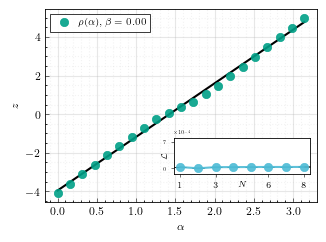

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

ax.plot(selected_alpha_noiseless[:,0],
            np.mean(selected_z_noiseless,axis=1),
            ls='',
            marker="o",
            markeredgewidth=0.5,
            alpha=0.9,
            label="$\\rho(\\alpha) , \\beta=0.00$",
            color=colors[2],
            zorder=3)


ax.plot(selected_alpha_noiseless[:,0], np.mean(vae_utils.linear_fit(selected_alpha_noiseless.flatten(), selected_z_noiseless.flatten())[0] ,axis=1),c="black")

rect = [0.475,0.145,0.5,0.5/(0.4/0.15)]
ax1 = add_subplot_axes(ax,rect)

ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$z$")
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.tick_params(direction="in", which="both", labelsize=8)
ax.tick_params(which="major", length=3)
ax.tick_params(which="minor", length=1.5)
ax.minorticks_on()


ax1.errorbar(lat_arr, 
            av_recon_loss_arr_noiseless.flatten(),
            std_recon_loss_arr_noiseless.flatten(),
            ls='-',
            marker="o",
            markeredgewidth=0.5,
            capsize=4, 
            capthick=1, 
            elinewidth=1,
            alpha=0.9,
            ecolor='black',
            color=colors[1])

ax1.set_xlabel("$N$",labelpad=-6)
ax1.set_ylabel("$\\mathcal{L}$",labelpad=-4)
ax1.xaxis.label.set_fontsize(1.3*4.6475800154489)
ax1.yaxis.label.set_fontsize(1.3*4.6475800154489)

ax1.set_ylim(-0.00015,0.0008)
ax1.set_yticks([0.00000,0.0007])
ax1.set_xticks([1,3,6,8])


ax1.ticklabel_format(axis="y", style="sci",scilimits=(0,0))

legend = ax.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

# plt.savefig("fig_exp1_new.pdf",bbox_inches="tight",pad_inches=0.1)

3.4641016151377544


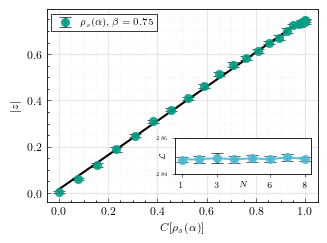

In [17]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

ax.errorbar(selected_conc_noisy[:,0],
            np.mean(np.abs(selected_z_noisy),axis=1),
            np.std(np.abs(selected_z_noisy),axis=1),
            ls='',
            marker="o",
            markeredgewidth=0.5,
            capsize=4, 
            capthick=1, 
            elinewidth=1,
            alpha=0.9,
            ecolor='black',
            label="$\\rho_s(\\alpha), \\beta=0.75$",
            color=colors[2],
            zorder=3
            )

ax.plot(selected_conc_noisy[:,0], 
        np.mean(vae_utils.linear_fit(selected_conc_noisy.flatten(), 
        np.abs(selected_z_noisy).flatten())[0] ,axis=1),
        c="black"
        )

rect = [0.475,0.145,0.5,0.5/(0.4/0.15)]
ax1 = add_subplot_axes(ax,rect)

ax.set_xlabel("$C[\\rho_s(\\alpha)]$")
ax.set_ylabel("$|z|$")
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.tick_params(direction="in", which="both", labelsize=8)
ax.tick_params(which="major", length=3)
ax.tick_params(which="minor", length=1.5)
ax.minorticks_on()


ax1.errorbar(lat_arr, 
             av_recon_loss_arr_noise_075.flatten(),
             std_recon_loss_arr_noise_075.flatten(),
             ls='-',
            marker="o",
            markeredgewidth=0.5,
            capsize=4, 
            capthick=1, 
            elinewidth=1,
            alpha=0.9,
            ecolor='black',
            color=colors[1])

           

ax1.set_xlabel("$N$",labelpad=-6)
ax1.set_ylabel("$\\mathcal{L}$",labelpad=-8)
ax1.xaxis.label.set_fontsize(1.3*4.6475800154489)
ax1.yaxis.label.set_fontsize(1.3*4.6475800154489)

ax1.set_xticks([1,3,6,8])

ax1.set_ylabel("$\\mathcal{L}$")
ax1.set_xlabel("$N$")
ax1.set_yticks([2.84,2.86])
ax1.set_xticks([1,3,6,8])

legend = ax.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)


# plt.savefig("fig_exp4_new.pdf",bbox_inches="tight",pad_inches=0.1)

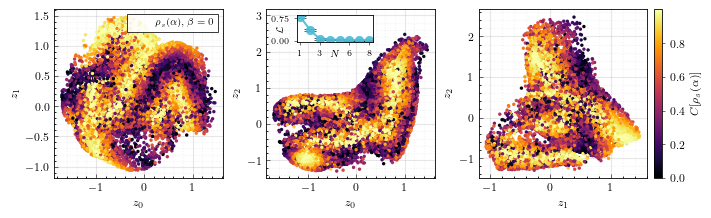

In [18]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(
    1, 3,
    figsize=(7.0, 2.6),
    constrained_layout=True
)

# --- main scatter plots ---
# Rasterize dense point clouds so PDF stays small and renders quickly.
sc0 = ax[0].scatter(
    z_mean_3d[:, 0], z_mean_3d[:, 1],
    c=concurrence_noisy_arr,
    zorder=2,
    label="$\\rho_s(\\alpha), \\beta=0$",
    cmap="inferno",
    s=6,
    linewidths=0,
    rasterized=True
)
sc1 = ax[1].scatter(
    z_mean_3d[:, 0], z_mean_3d[:, 2],
    c=concurrence_noisy_arr,
    zorder=2,
    cmap="inferno",
    s=6,
    linewidths=0,
    rasterized=True
)
im = ax[2].scatter(
    z_mean_3d[:, 1], z_mean_3d[:, 2],
    c=concurrence_noisy_arr,
    zorder=2,
    cmap="inferno",
    s=6,
    linewidths=0,
    rasterized=True
)

# --- square axes ---
for a in ax:
    a.set_box_aspect(1)

# --- labels ---
ax[0].set_xlabel("$z_0$")
ax[0].set_ylabel("$z_1$")

ax[1].set_xlabel("$z_0$")
ax[1].set_ylabel("$z_2$")

ax[2].set_xlabel("$z_1$")
ax[2].set_ylabel("$z_2$")

# --- grids ---
for a in ax:
    a.grid(True, which="major", linestyle="-", alpha=0.3)
    a.grid(True, which="minor", linestyle=":", alpha=0.15)
    a.tick_params(direction="in", which="both", labelsize=8)
    a.tick_params(which="major", length=3)
    a.tick_params(which="minor", length=1.5)
    a.minorticks_on()

# --- inset using axis-fraction coordinates (x0, y0, w, h) ---
axins = inset_axes(
    ax[1],
    width="100%",
    height="65%",
    loc="upper left",
    bbox_to_anchor=(0.03 + 0.15, 0.72, 0.45, 0.25),
    bbox_transform=ax[1].transAxes,
    borderpad=0
)

axins.errorbar(
    lat_arr,
    av_recon_loss_arr_noise.flatten(),
    std_recon_loss_arr_noise.flatten(),
    ls='-',
    marker="o",
    markeredgewidth=0.5,
    capsize=4,
    capthick=1,
    elinewidth=1,
    alpha=0.9,
    ecolor='black',
    color=colors[1])

axins.set_xticks([1, 3, 6, 8])
axins.set_yticks([0, 0.75])
axins.tick_params(labelsize=6)

ax[1].set_ylim(-1.4858809113502502, 3.1643131375312805)

ax[1].text(-0.55, 1.87, "$N$", fontsize=7)
ax[1].text(-1.65, 2.55, "$\\mathcal{L}$", fontsize=7, rotation=90)

# --- colorbar ONLY for right subplot ---
cbar = fig.colorbar(im, ax=ax[2], fraction=0.05, pad=0.04)
cbar.set_label("$C[\\rho_s(\\alpha)]$")

legend = ax[0].legend(
    frameon=True,
    loc="best",
    fontsize=7,
    ncol=1,
    columnspacing=1.0,
    handletextpad=0.5,
    framealpha=0.9,
    edgecolor="black",
    fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

# plt.savefig("fig_exp2_new.pdf", dpi=300)


In [19]:
slope, intercept, r_value, p_value, std_err = linregress(selected_conc_noisy[:,0],np.mean(np.abs(selected_z_noisy),axis=1))
np.round(r_value**2,3)

np.float64(0.999)

In [20]:
slope, intercept, r_value, p_value, std_err = linregress(selected_conc_noisy[:,0],np.mean(np.concatenate((np.abs(pred_conc_noisy),np.abs(pred_conc_generalized)),axis=1),axis=1))
np.round(r_value**2,3)

np.float64(0.999)